In [68]:
version
#https://cloud.tencent.com/developer/article/1332506

               _                           
platform       x86_64-conda-linux-gnu      
arch           x86_64                      
os             linux-gnu                   
system         x86_64, linux-gnu           
status                                     
major          4                           
minor          4.2                         
year           2024                        
month          10                          
day            31                          
svn rev        87279                       
language       R                           
version.string R version 4.4.2 (2024-10-31)
nickname       Pile of Leaves              

In [69]:
library("ChIPseeker")

In [70]:
library("org.Hs.eg.db")
library("TxDb.Hsapiens.UCSC.hg38.knownGene")
library("clusterProfiler")
txdb <- TxDb.Hsapiens.UCSC.hg38.knownGene

In [71]:
library("org.Hs.eg.db")
library("TxDb.Hsapiens.UCSC.hg38.knownGene")
library("clusterProfiler")
txdb <- TxDb.Hsapiens.UCSC.hg38.knownGene

In [72]:
setwd("/mnt/zhangzheng_group/liuz-53/other/ENCSR230ZWH_GSE95993/RAD21_human/GSM2527619/SRR5331454")
rep1<-readPeakFile("rep1_peaks.narrowPeak_clean")

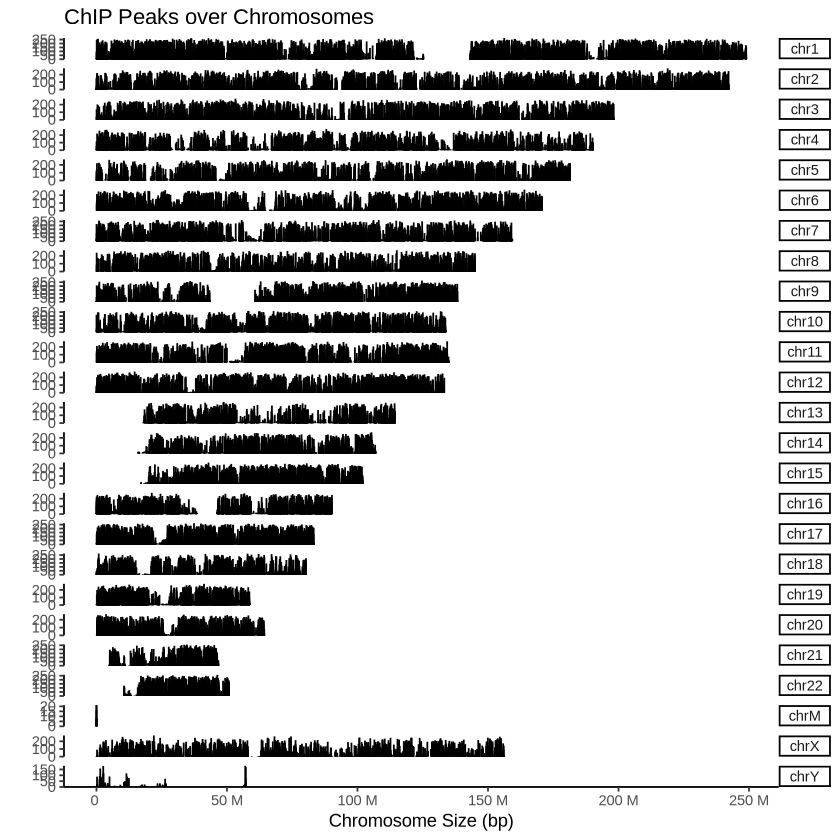

In [36]:
covplot(rep1,weightCol=5)

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


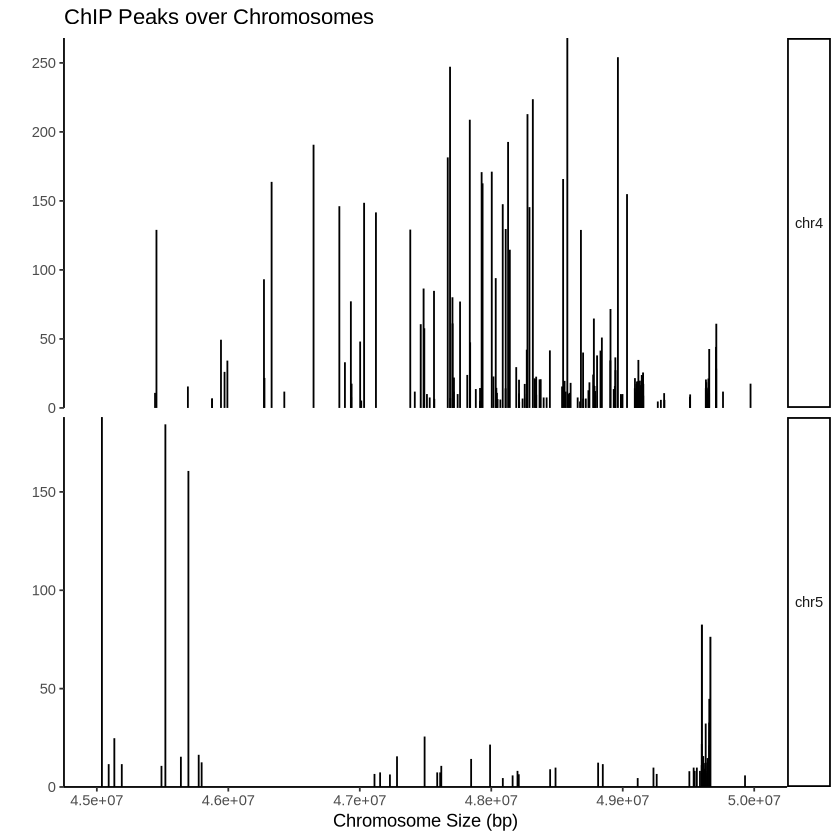

In [37]:
covplot(rep1, weightCol=5, chrs=c("chr4", "chr5"), xlim=c(4.5e7, 5e7))

In [40]:
promoter <- getPromoters(TxDb=txdb, upstream=3000, downstream=3000)

In [41]:
rep1

GRanges object with 135720 ranges and 7 metadata columns:
           seqnames            ranges strand |   rep1_peak_3716      X332
              <Rle>         <IRanges>  <Rle> |      <character> <integer>
       [1]     chr1       11170-11490      * |   rep1_peak_3717       931
       [2]     chr1       26003-26137      * |   rep1_peak_3718        75
       [3]     chr1       29280-29441      * |   rep1_peak_3719        82
       [4]     chr1       91196-91680      * |   rep1_peak_3720      2383
       [5]     chr1     102690-103068      * |   rep1_peak_3721       128
       ...      ...               ...    ... .              ...       ...
  [135716]     chrY 57153497-57153677      * | rep1_peak_139432       145
  [135717]     chrY 57158312-57158473      * | rep1_peak_139433       186
  [135718]     chrY 57203245-57203579      * | rep1_peak_139434       718
  [135719]     chrY 57215146-57215433      * | rep1_peak_139435       286
  [135720]     chrY 57216787-57217323      * | rep1_pe

In [44]:
tagMatrix <- getTagMatrix(rep1, windows=promoter)

>> preparing start_site regions by gene... 2025-01-22 07:49:52 AM
>> preparing tag matrix...  2025-01-22 07:49:52 AM 


In [46]:
?tagHeatmap

tagHeatmap {ChIPseeker},R Documentation
tagMatrix,tagMatrix or a list of tagMatrix
xlab,xlab
ylab,ylab
title,title
palette,"palette to be filled in,details see scale_colour_brewer"
nrow,the nrow of plotting a list of peak
ncol,the ncol of plotting a list of peak


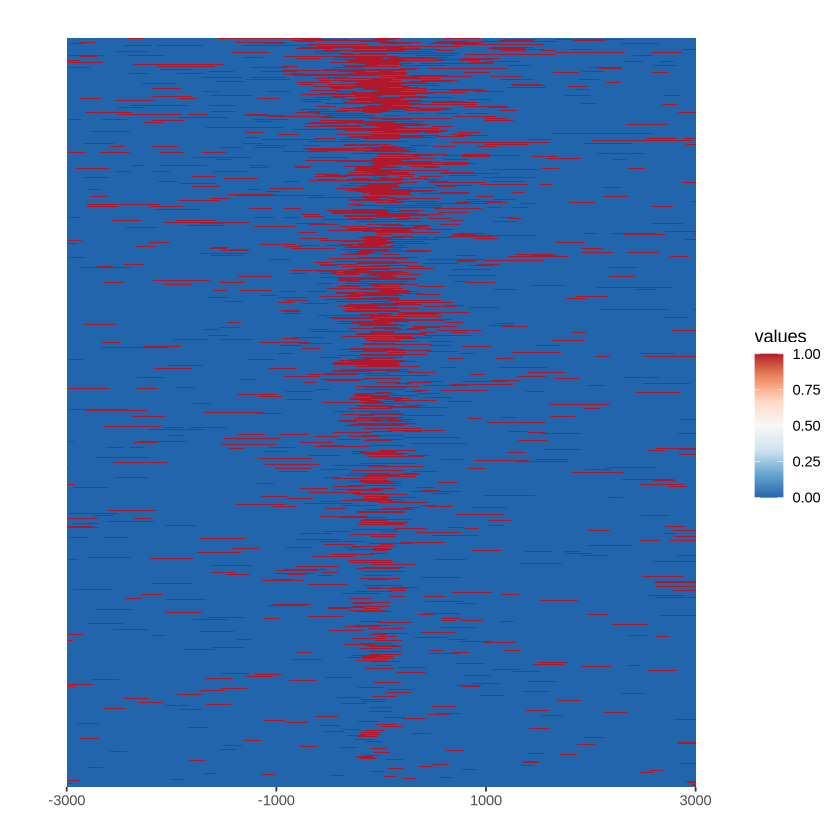

In [73]:
tagHeatmap(tagMatrix)

>> preparing promoter regions...	 2025-01-22 08:05:02 AM 
>> preparing tag matrix...		 2025-01-22 08:05:02 AM 
>> preparing start_site regions by gene... 2025-01-22 08:05:02 AM
>> preparing tag matrix...  2025-01-22 08:05:02 AM 
>> generating figure...		 2025-01-22 08:05:12 AM 
>> done...			 2025-01-22 08:05:21 AM 


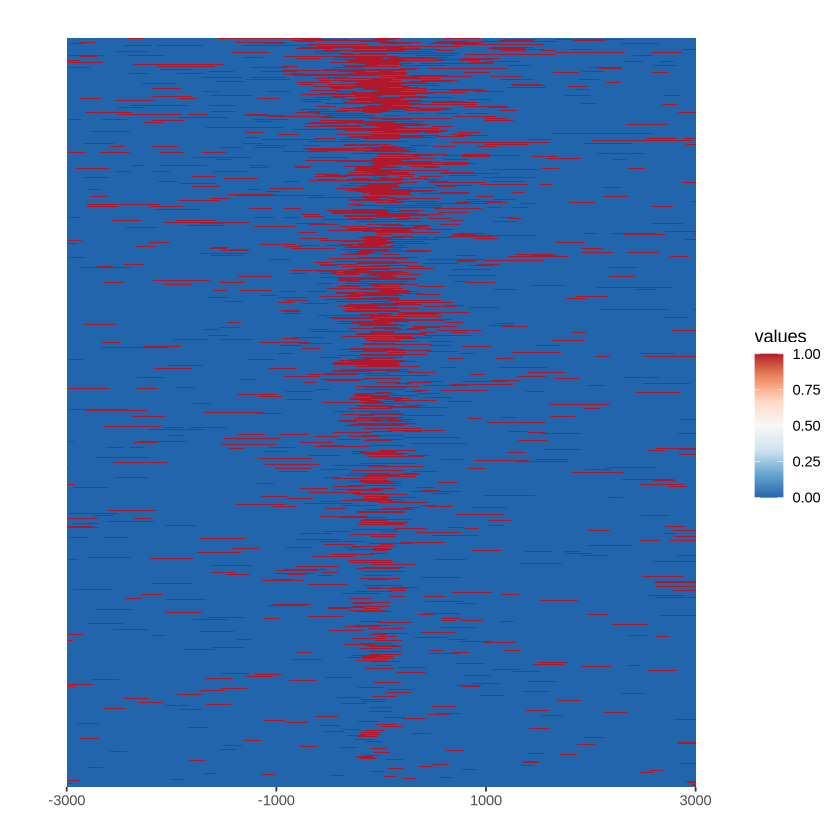

In [49]:
peakHeatmap(热评, TxDb=txdb, upstream=3000, downstream=3000, color="blue")

>> plotting figure...			 2025-01-22 07:59:00 PM 
>> Running bootstrapping for tag matrix...		 2025-01-22 07:59:33 PM 


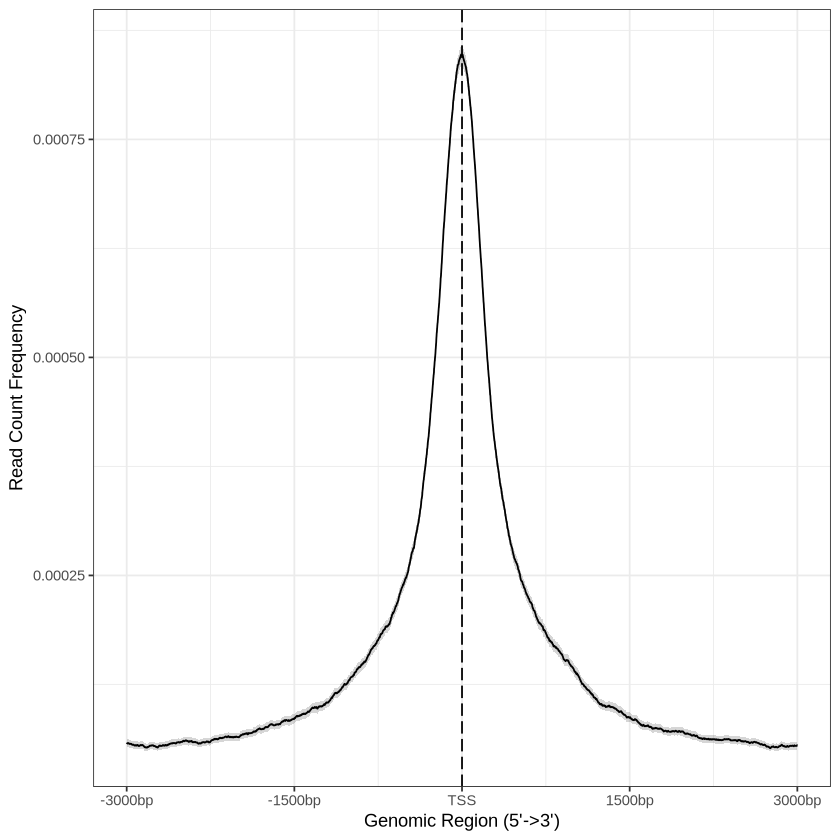

In [50]:
plotAvgProf(tagMatrix, xlim=c(-3000, 3000),
            conf=0.95,resample = 1000,
            xlab="Genomic Region (5'->3')", ylab = "Read Count Frequency")

In [51]:
peakAnno <- annotatePeak(rep1, tssRegion=c(-3000, 3000),
                         TxDb=txdb, annoDb="org.Hs.eg.db")

>> preparing features information...		 2025-01-22 08:19:38 PM 
>> identifying nearest features...		 2025-01-22 08:19:40 PM 
>> calculating distance from peak to TSS...	 2025-01-22 08:19:41 PM 
>> assigning genomic annotation...		 2025-01-22 08:19:41 PM 
>> adding gene annotation...			 2025-01-22 08:20:09 PM 


'select()' returned 1:many mapping between keys and columns



>> assigning chromosome lengths			 2025-01-22 08:20:10 PM 
>> done...					 2025-01-22 08:20:10 PM 


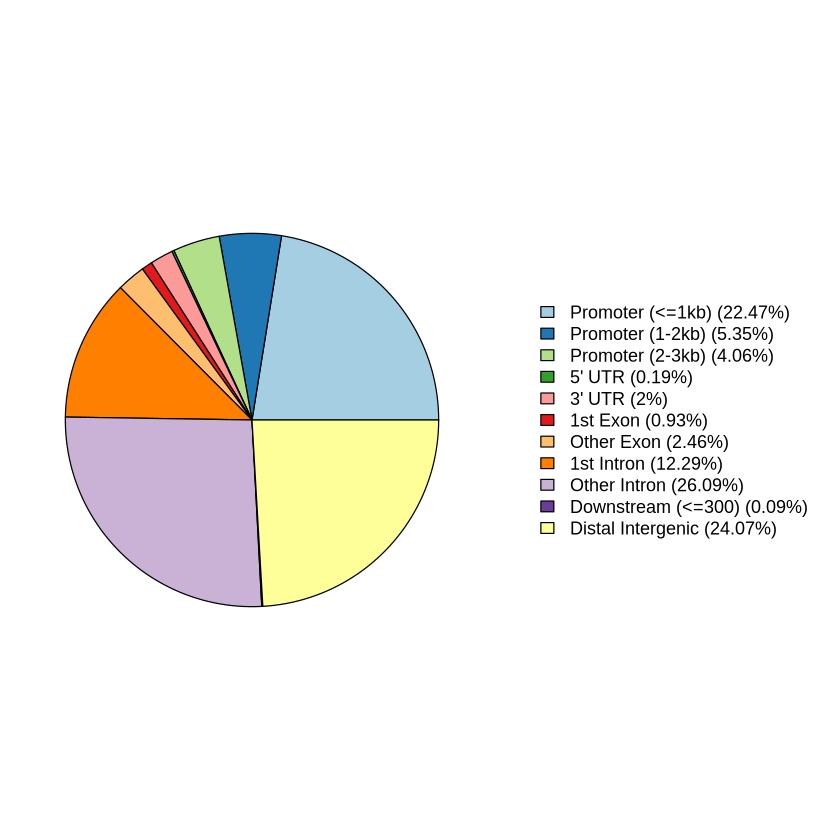

In [52]:
plotAnnoPie(peakAnno)


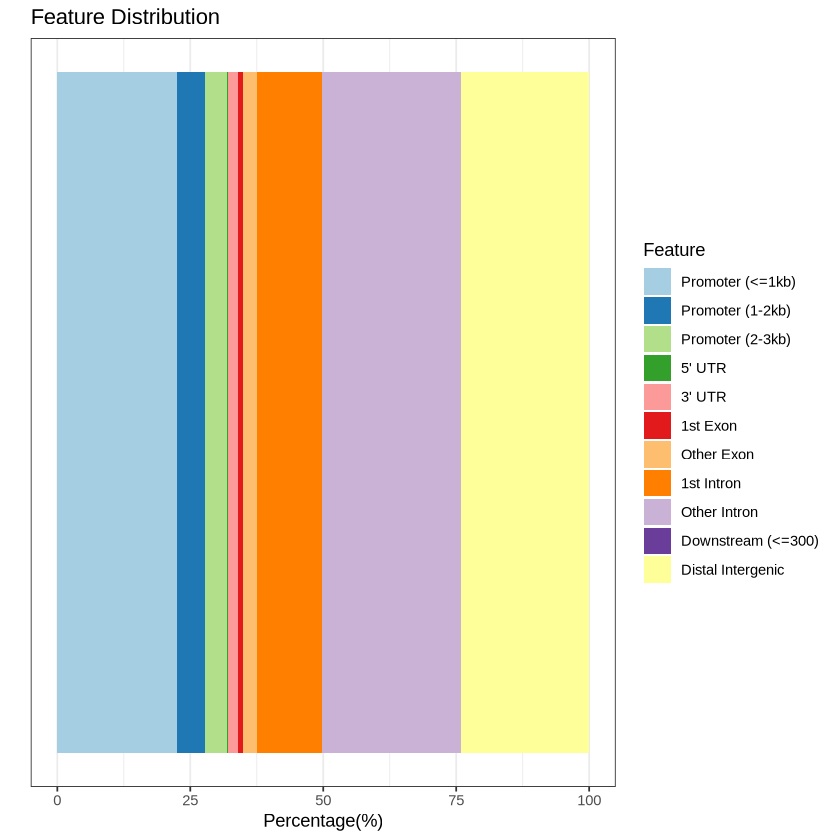

In [53]:
plotAnnoBar(peakAnno)


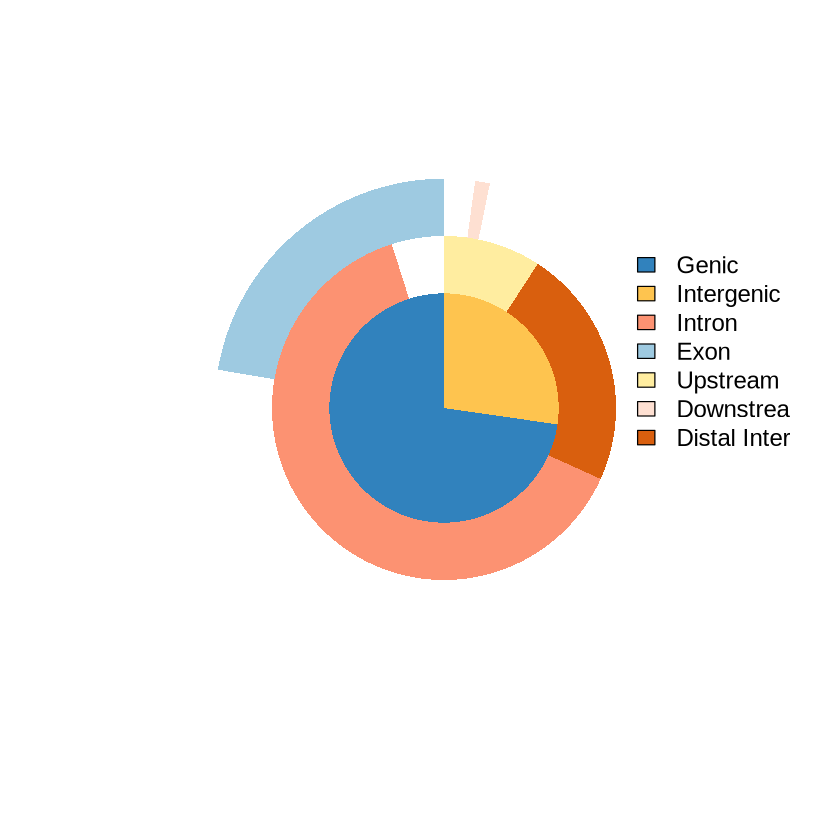

In [54]:
vennpie(peakAnno)


Warning message:
“Removed 786 rows containing non-finite outside the scale range (`stat_count()`).”


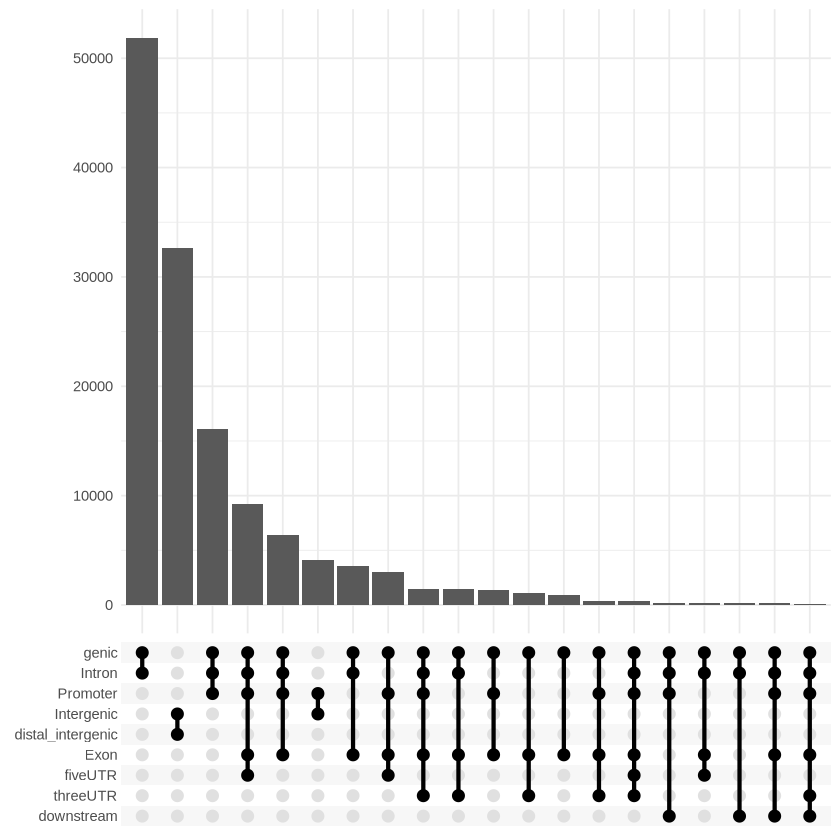

In [56]:
upsetplot(peakAnno)


Warning message:
“Removed 786 rows containing non-finite outside the scale range (`stat_count()`).”


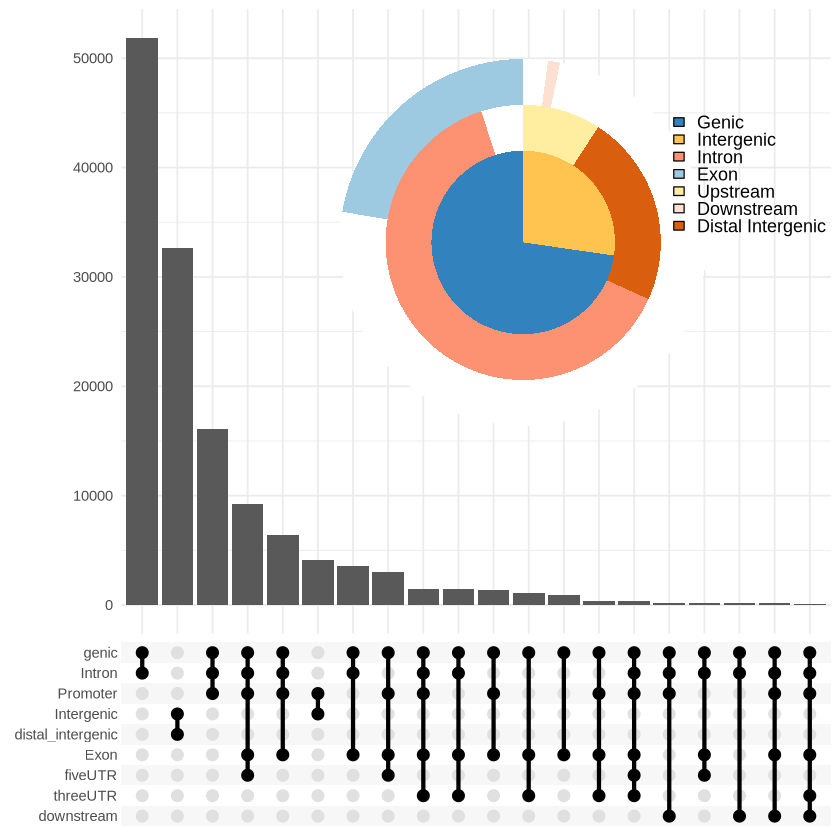

In [58]:
upsetplot(peakAnno, vennpie=TRUE)


In [59]:
peakAnnoList <- as.data.frame(peakAnno)

In [61]:
dim(peakAnnoList)
head(peakAnnoList)

[1] 135713     24

,seqnames,start,end,width,strand,rep1_peak_3716,X332,.,X9.45042,X35.84444,⋯,geneStart,geneEnd,geneLength,geneStrand,geneId,transcriptId,distanceToTSS,ENSEMBL,SYMBOL,GENENAME
,<fct>,<int>,<int>,<int>,<fct>,<chr>,<int>,<chr>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
1,chr1,11170,11490,321,*,rep1_peak_3717,931,.,17.31188,96.22988,⋯,11869,14409,2541,1,100287102,ENST00000456328.2,-379,ENSG00000290825,DDX11L1,DEAD/H-box helicase 11 like 1 (pseudogene)
2,chr1,26003,26137,135,*,rep1_peak_3718,75,.,4.65549,9.70469,⋯,14696,24886,10191,2,653635,ENST00000488147.2,-1117,NA,WASH7P,"WASP family homolog 7, pseudogene"
3,chr1,29280,29441,162,*,rep1_peak_3719,82,.,5.02898,10.48148,⋯,29554,31097,1544,1,107985730,ENST00000473358.1,-113,NA,MIR1302-2HG,MIR1302-2 host gene
4,chr1,91196,91680,485,*,rep1_peak_3720,2383,.,25.28527,243.42036,⋯,65419,71585,6167,1,79501,ENST00000641515.2,25777,ENSG00000186092,OR4F5,olfactory receptor family 4 subfamily F member 5
5,chr1,102690,103068,379,*,rep1_peak_3721,128,.,5.34688,15.18959,⋯,92230,129217,36988,2,124900384,ENST00000477740.5,26149,NA,LOC124900384,uncharacterized LOC124900384
6,chr1,104837,105244,408,*,rep1_peak_3722,599,.,13.28228,62.78171,⋯,92230,129217,36988,2,124900384,ENST00000477740.5,23973,NA,LOC124900384,uncharacterized LOC124900384


In [62]:
genes<-peakAnnoList$geneId
head(genes)

[1] "100287102" "653635"    "107985730" "79501"     "124900384" "124900384"

In [66]:
geneSym<-peakAnnoList$SYMBOL
head(geneSym)
length(geneSym)
length(unique(geneSym))

[1] "DDX11L1"      "WASH7P"       "MIR1302-2HG"  "OR4F5"        "LOC124900384"
[6] "LOC124900384"

[1] 135713

[1] 26287

In [67]:
write.csv(peakAnnoList, "Rep1_peak_anno.csv", quote = F)

In [ ]:

> names(genes)
[1] "ARmo_0M"    "ARmo_1nM"   "ARmo_100nM" "CBX6_BF"    "CBX7_BF"  
                
# 然后作图(需要借助Vennerable包)
devtools::install_github("js229/Vennerable")
library(Vennerable)
vennplot(genes[2:4], by='Vennerable')

In [ ]:
plotDistToTSS(peakAnno,
              title="Distribution of transcription factor-binding loci\nrelative to TSS")
